# Peaks, indexing and a Le Bail check

*Written by Claude Code, Anthropic's coding agent, for the rietx project.*

When the phase is unknown there is no CIF to start from.
The cell has to come from the peak positions alone: find the peaks, then search for a cell that puts a reflection under each one.
That search is called indexing.
We index a synthetic pattern whose answer we know, read why rietx declines to name a single cell, and check the best candidate with a Le Bail fit.

**You need** rietx 1.7 or later, which the next cell installs.
Notebook 01 introduces Le Bail fitting.

**The data** is synthetic aragonite, CaCO₃, made from its published structure: Dal Negro and Ungaretti (1971), *American Mineralogist* 56, 768, as entry 9000229 of the Crystallography Open Database (public domain).
The displacement parameters are the isotropic equivalents of that entry's anisotropic ones.

**Runtime** is under a minute on a laptop, most of it the indexing search.

In [ ]:
%pip install rietx

## A synthetic pattern

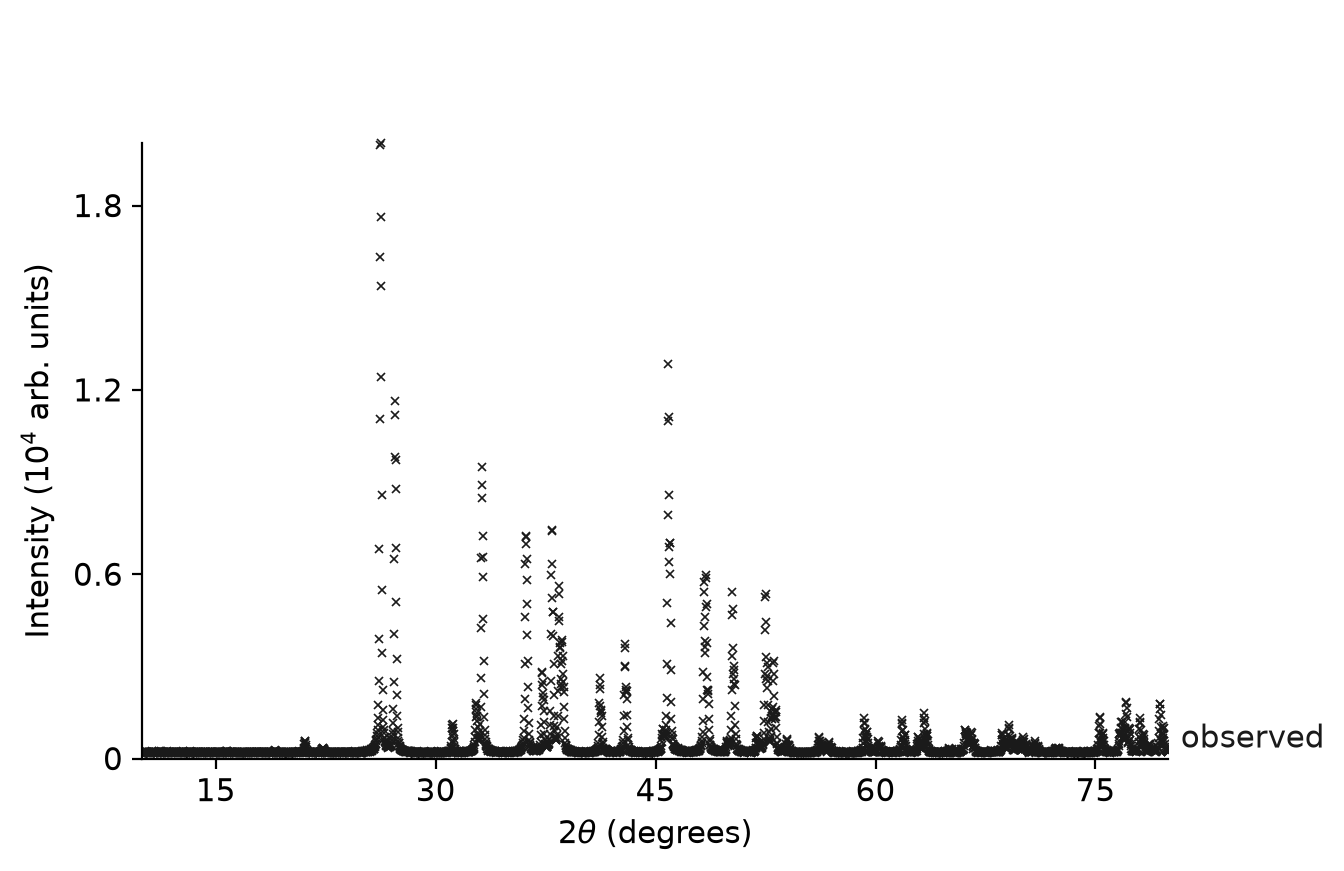

In [1]:
import tempfile
from pathlib import Path

import numpy as np

import rietx as rx
from rietx.indexing import SearchSpec, structure_from_candidate

work = Path(tempfile.mkdtemp())
cif = work / "aragonite.cif"
cif.write_text(
    "data_aragonite\n_space_group_name_H-M_alt 'P m c n'\n"
    "_cell_length_a 4.9616\n_cell_length_b 7.9705\n_cell_length_c 5.7394\n"
    "_cell_angle_alpha 90\n_cell_angle_beta 90\n_cell_angle_gamma 90\n"
    "loop_\n_atom_site_label\n_atom_site_type_symbol\n_atom_site_fract_x\n"
    "_atom_site_fract_y\n_atom_site_fract_z\n_atom_site_B_iso_or_equiv\n"
    "Ca1 Ca 0.25 0.4151 0.2403 0.67\n"
    "C1  C  0.25 0.7627 0.0850 0.80\n"
    "O1  O  0.25 0.9231 0.0952 1.25\n"
    "O2  O  0.4729 0.6801 0.0870 1.19\n",
    encoding="utf-8")
truth = rx.Structure.from_cif(cif)

true_instrument = rx.Instrument.bragg_brentano(radiation="CuKa")
true_instrument.profile.w.value = 0.004
true_instrument.profile.x.value = 0.05
true_instrument.background = rx.BackgroundChebyshev.with_terms(1)
true_instrument.background.coefficients[0].value = 200.0

two_theta = np.arange(10, 80, 0.02)
y = rx.Refinement(truth, true_instrument).predict(two_theta) - 200.0
truth.phases[0].scale.value *= 20000 / y.max()   # strongest peak about 20 000 counts
y = rx.Refinement(truth, true_instrument).predict(two_theta)
data = rx.PatternData(two_theta=two_theta,
                      intensity=np.random.default_rng(0).poisson(y).astype(float))
data.plot()

From here on we pretend not to know the structure.
The true cell is a = 4.9616, b = 7.9705, c = 5.7394 Å, and the indexer should find it in some order of axes.

## Find the peaks

`pick_peaks` finds every resolvable peak and fits each one for its position, with an esd.
It needs an instrument for the wavelength and a first guess at the peak width.
We give it a default copper instrument, as you would for an unknown sample.

In [2]:
lab = rx.Instrument.bragg_brentano(radiation="CuKa")
peaks = rx.pick_peaks(data, lab)
peaks

#,two_theta,two_theta_esd,intensity,fwhm,origin,flags
0,21.0739,0.0024,31.4,0.101,fitted,
1,22.2946,0.0056,9.6,0.084,fitted,
2,26.2221,0.0003,2175.4,0.096,fitted,asymmetry_unmodelled
3,26.6192,0.0106,18.1,0.095,fitted,asymmetry_unmodelled
4,27.2200,0.0004,1241.7,0.095,fitted,asymmetry_unmodelled
5,31.1394,0.0016,92.8,0.110,fitted,
6,32.7501,0.0010,170.8,0.096,fitted,asymmetry_unmodelled
7,32.7600,0.0019,168.7,0.097,fitted,"position_at_bound, asymmetry_unmodelled, duplicate_line"
8,33.1523,0.0003,1066.9,0.096,fitted,asymmetry_unmodelled
9,33.1524,0.0006,1065.8,0.097,fitted,"asymmetry_unmodelled, duplicate_line"


Each row is one peak: its position, the esd of that position, its area and its width.
`flags` records anything the fit noticed.
A flagged peak can still be usable, and the count line says how many are.

The diagnostics under the table explain the list.
`PEAK_WIDTH_LAW_MISMATCH` says the peaks are about five times wider than the default instrument predicts, so the picker scaled its windows to match.
`PEAK_KALPHA2_ALIAS` counts candidates it dropped as the Kα2 partner of a stronger line: each reported position is a Kα1 position.

## Measure lines you name

`fit_peaks` fits exactly the positions you give it, and nothing else.
Use it to measure lines you have chosen: a few reflections for a size analysis, or one line as a quick check.

In [3]:
chosen = rx.fit_peaks(data, lab, [26.22, 27.22, 33.13])
chosen

#,two_theta,two_theta_esd,intensity,fwhm,origin,flags
0,26.2221,0.0003,2175.4,0.096,manual,asymmetry_unmodelled
1,27.2199,0.0006,1246.2,0.094,manual,"asymmetry_unmodelled, unnamed_neighbour"
2,33.1514,0.0031,1113.5,0.092,manual,"asymmetry_unmodelled, unnamed_neighbour"


Rebuilding a whole list from edited positions in code works less well: a real line you leave out still has intensity, and its neighbours absorb it.

## The same work in the GUI

Editing a peak list is easier by hand, and rietx has a graphical mode for it.
Run `rietx gui` in a terminal, open or create a project with your pattern, and choose the Peaks tab.
The plot then becomes an editing surface:

| Gesture | Does |
|---|---|
| click empty space | add a line, measured by `fit_peaks` |
| drag a marker | move it |
| shift-click | exclude a line from indexing |
| right-click | remove it |

The same tab runs the indexing search, draws a candidate's predicted lines over the pattern, and adopts a candidate as the starting point of a Le Bail fit.
Every gesture also has a typed equivalent in the panel.
The [GUI guide](https://rietx.org/using/gui-guide.html#peaks) covers the tab in full.

## Index

`index_pattern` searches for cells that index the usable peaks.
A search over every crystal system can take minutes, so we narrow it.
We search only orthorhombic cells, with a volume between 200 and 250 Å³ and no axis longer than 8.5 Å.
Those limits come from knowing the answer.
With a real unknown, start from the formula and a wide window, and let the search run longer.

In [4]:
spec = SearchSpec(systems=("orthorhombic",), min_volume=200, max_volume=250, max_d_axis=8.5)
indexing = rx.index_pattern(peaks, data=data, instrument=lab, spec=spec)
indexing

#,confidence,lattice,a b c (Å),α β γ (°),V (Å³),indexed,chi2_red,Le Bail Rwp,confidence_caveats
1,low,orthorhombic P,4.96150 5.73930 7.97038,90.000 90.000 90.000,226.96,50/59,0.22,0.2570,"predicted_but_absent, indexed_fraction_low"


The top candidate is the true cell, with its axes in a different order.
All three search engines found it.

Yet the result abstains: `best_or_none()` returns `None`, and the verdict line says NO CELL.
rietx names a single cell only when exactly one candidate reaches high confidence, and this one is low for the reasons in its row.

- `predicted_but_absent`: the indexer checks a candidate in the lattice's highest-symmetry space group, which has no systematic absences. Aragonite's real space group, Pmcn, has glide planes that remove some reflections. Those reflections are predicted but absent.
- `indexed_fraction_low`: some usable lines are not indexed. A few of them are weak false lines the picker found beside strong peaks.

The candidate's `INDEX_IMPURITY_LINES` warning comes from the indexer's own quick Le Bail fit, whose Rwp in the table is poor.
A poor fit leaves many peaks unmatched, so that count is not evidence of a second phase.
Our own Le Bail fit below settles it.

In [5]:
print(indexing.best_or_none())
candidate = indexing.candidates[0]
print(candidate.cell, candidate.confidence_caveats)

None
(4.961504341308777, 5.7392991240231845, 7.9703799717669055, 90.0, 90.0, 90.0) ['predicted_but_absent', 'indexed_fraction_low']


## Check the candidate with Le Bail

`structure_from_candidate` turns a candidate into a structure for Le Bail fitting.
It uses the lattice's highest-symmetry space group (here P m m m), so the fit tests the lattice and nothing else.
As in notebook 01, we start the background at the data's floor and run the plan twice.

In [6]:
structure = structure_from_candidate(candidate)
print(structure.phases[0].space_group)

instrument = rx.Instrument.bragg_brentano(radiation="CuKa")
instrument.background = rx.BackgroundChebyshev.with_terms(4)
instrument.background.coefficients[0].value = float(np.percentile(data.intensity, 5))
ref = rx.Refinement(structure, instrument)
passes = [ref.fit(data, mode="lebail", plan="profile_only") for _ in range(2)]
best = min(passes, key=lambda r: r.statistics.rwp)
print(f"Rwp by pass: {[round(r.statistics.rwp, 4) for r in passes]}")
for edge in "abc":
    p = best.parameter(f"phases.0.cell.{edge}")
    print(f"{edge} = {p.value:.5f} +/- {p.stderr:.5f} Å")

P m m m


Rwp by pass: [0.0707, 0.0607]
a = 4.96156 +/- 0.00008 Å
b = 5.73953 +/- 0.00009 Å
c = 7.97054 +/- 0.00013 Å


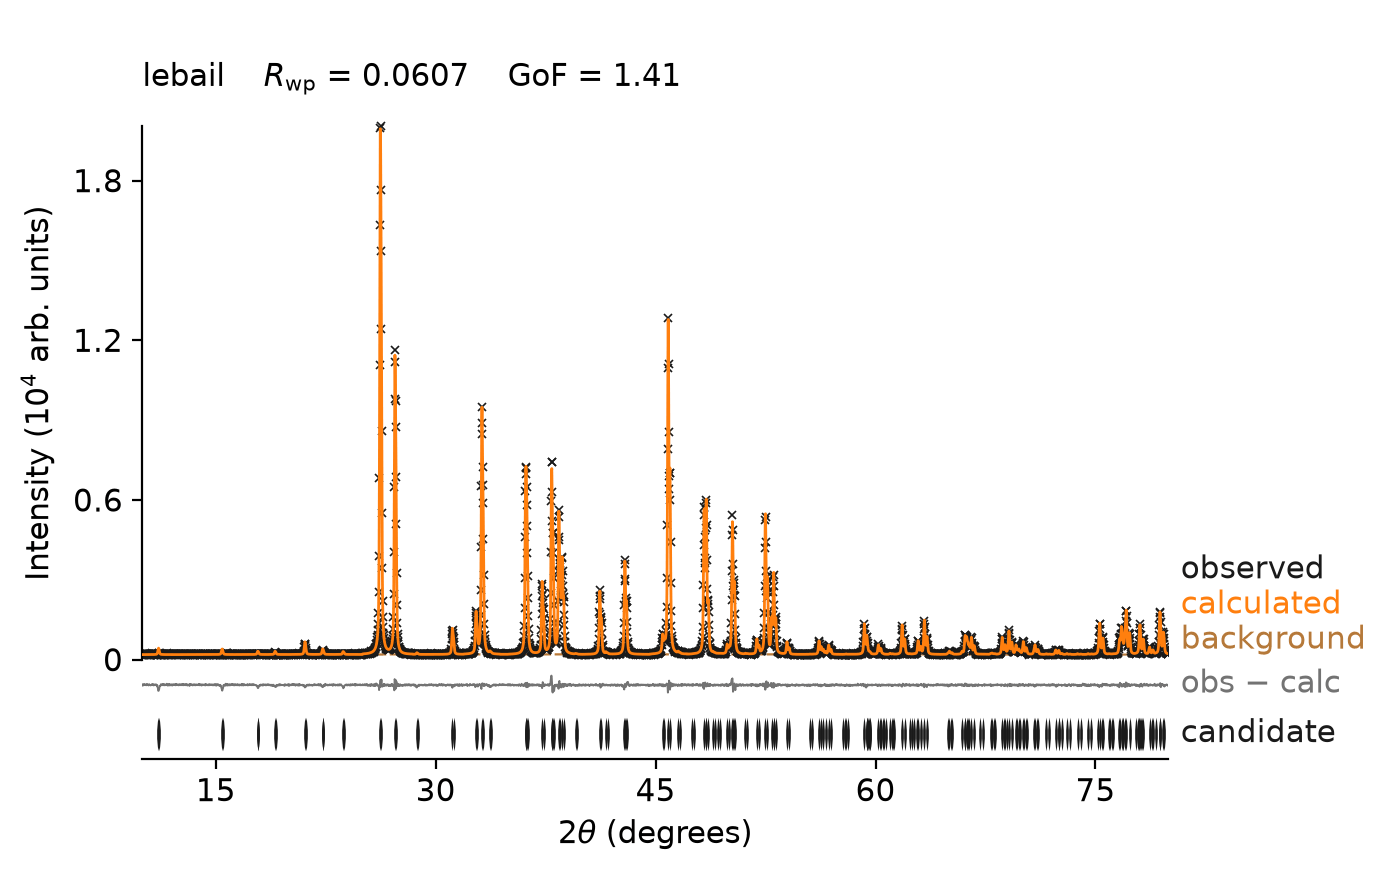

In [7]:
best.plot()

The fit puts a reflection under every peak and leaves only small residuals, so the lattice is right.
The refined edges match the true cell, in the candidate's order of axes.

Some ticks stand over no peak, such as those near 11° and 15.5°.
They are reflections P m m m allows and aragonite's glide planes remove: the indexer's predicted-but-absent reflections.

What this does not settle is the space group.
That is a question about which reflections are absent, and it comes after the cell is refined.

## Checking an agent's work

When an agent reports a cell it indexed, check these.
The rules are in the rietx agent skill (`SKILL.md` §6, and `references/diagnostics-indexing.md`).

- **Did `best_or_none()` return a cell?** If not, the agent chose one. Ask why, and read the chosen candidate's `confidence_caveats` (rule 19).
- **What was searched?** A search narrowed by system, volume or axis length says nothing about the cells outside it. `INDEX_SYSTEMS_NOT_COVERED` and `INDEX_SEARCH_INCOMPLETE` say what was left out.
- **Was the cell checked with a whole-pattern fit?** A Le Bail fit of the candidate should leave no peak unexplained.
- **Is the space group a separate claim?** A cell from indexing comes with the lattice's highest-symmetry group. The real space group needs its own evidence.